
## Notebook 01 – Dataset Exploration


In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm.notebook import tqdm

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
from pathlib import Path

ROOT = Path("..")

DATASET_DIR = ROOT / "Dataset"

TRAIN_PATH = DATASET_DIR / "train.csv"
MERGED_DIR = DATASET_DIR / "merged"

print("Train exists :", TRAIN_PATH.exists())
print("Merged exists:", MERGED_DIR.exists())

Train exists : True
Merged exists: True


In [3]:
train_df = pd.read_csv(TRAIN_PATH)

print(f"Shape: {train_df.shape}")

train_df.head()

Shape: (1804874, 45)


,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,bisexual,black,buddhist,christian,female,heterosexual,hindu,homosexual_gay_or_lesbian,intellectual_or_learning_disability,jewish,latino,male,muslim,other_disability,other_gender,other_race_or_ethnicity,other_religion,other_sexual_orientation,physical_disability,psychiatric_or_mental_illness,transgender,white,created_date,publication_id,parent_id,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59848,0.000000,"This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!",0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-09-29 10:50:41.987077+00,2,NaN,2006,rejected,0,0,0,0,0,0.0,0,4
1,59849,0.000000,"Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!",0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-09-29 10:50:42.870083+00,2,NaN,2006,rejected,0,0,0,0,0,0.0,0,4
2,59852,0.000000,This is such an urgent design problem; kudos to you for taking it on. Very impressive!,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-09-29 10:50:45.222647+00,2,NaN,2006,rejected,0,0,0,0,0,0.0,0,4
3,59855,0.000000,Is this something I'll be able to install on my site? When will you be releasing it?,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-09-29 10:50:47.601894+00,2,NaN,2006,rejected,0,0,0,0,0,0.0,0,4
4,59856,0.893617,haha you guys are a bunch of losers.,0.021277,0.0,0.021277,0.87234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-09-29 10:50:48.488476+00,2,NaN,2006,rejected,0,0,0,1,0,0.0,4,47


In [4]:
train_df.shape
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1804874 entries, 0 to 1804873
Data columns (total 45 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   id                                   int64  
 1   target                               float64
 2   comment_text                         str    
 3   severe_toxicity                      float64
 4   obscene                              float64
 5   identity_attack                      float64
 6   insult                               float64
 7   threat                               float64
 8   asian                                float64
 9   atheist                              float64
 10  bisexual                             float64
 11  black                                float64
 12  buddhist                             float64
 13  christian                            float64
 14  female                               float64
 15  heterosexual                         float6

In [5]:
missing = (
    train_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

missing["Percent"] = (
    missing["Missing"] / len(train_df) * 100
).round(2)

missing.head(50)

,Missing,Percent
buddhist,1399744,77.55
atheist,1399744,77.55
bisexual,1399744,77.55
black,1399744,77.55
asian,1399744,77.55
latino,1399744,77.55
jewish,1399744,77.55
intellectual_or_learning_disability,1399744,77.55
homosexual_gay_or_lesbian,1399744,77.55
hindu,1399744,77.55


In [6]:
train_df["target"].describe()

count    1.804874e+06
mean     1.030173e-01
std      1.970757e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.666667e-01
max      1.000000e+00
Name: target, dtype: float64

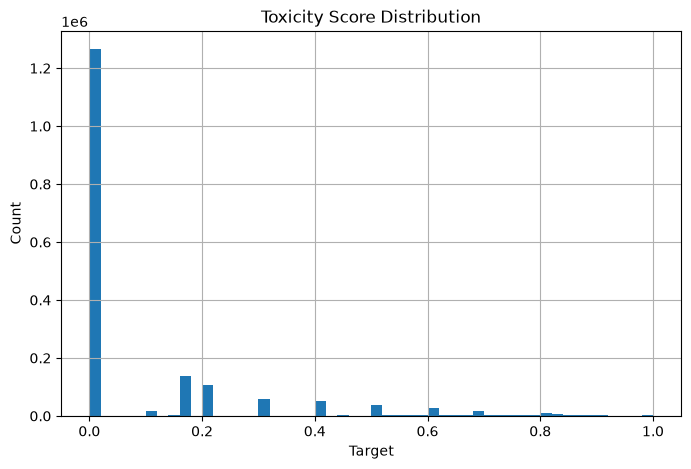

In [7]:
plt.figure(figsize=(8,5))

train_df["target"].hist(bins=50)

plt.title("Toxicity Score Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [8]:
train_df["is_toxic"] = train_df["target"] >= 0.5

train_df["is_toxic"].value_counts()

is_toxic
False    1660540
True      144334
Name: count, dtype: int64

In [9]:
train_df["is_toxic"].value_counts(normalize=True) * 100

is_toxic
False    92.003098
True      7.996902
Name: proportion, dtype: float64

In [10]:
identity_cols = [
    "male",
    "female",
    "transgender",
    "heterosexual",
    "homosexual_gay_or_lesbian",
    "black",
    "white",
    "asian",
    "latino",
    "muslim",
    "christian",
    "jewish"
]

train_df[identity_cols].describe()

,male,female,transgender,heterosexual,homosexual_gay_or_lesbian,black,white,asian,latino,muslim,christian,jewish
count,405130.000000,405130.000000,405130.000000,405130.000000,405130.000000,405130.000000,405130.00000,405130.000000,405130.000000,405130.000000,405130.000000,405130.000000
mean,0.108687,0.127670,0.006724,0.003237,0.025611,0.034393,0.05695,0.011964,0.006127,0.049460,0.095268,0.017863
std,0.267894,0.305384,0.069027,0.045801,0.143739,0.167900,0.21596,0.087166,0.058684,0.202459,0.256671,0.122145
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
train_df.loc[
    train_df["target"] > 0.9,
    ["comment_text", "target"]
].sample(10, random_state=42)

,comment_text,target
549891,"How many Jewish-majority countries are there in the world? One, with a total population of barely 10 million.\n\nAnd that country is a constitutional democracy, with full rights and freedoms for ...",1.000000
1380920,The blacks are the ones that are racists. They hate white people and do not hesitate to let them know that fact. Ridiculous waste of time and energy in this article. Just trying to make white peop...,0.914286
904667,"In the private sector, employment retention is NOT the same as being enrolled in the public school system. If you don't understand the difference, that's ignorance on your part.",1.000000
1021346,It's those damned Lutherans again!,0.962500
167646,"Yup. And, for those who weren’t around or have since gone senile, Republicans thought the Heritage Foundation plan was an awesome response to Hitlerycare. (That was back when they were the Party o...",1.000000
39615,"I liked the part where Mr. Hammer's comment states “The problem is it’s a civil (dispute), it’s not criminal ... and the police officer made a mistake and can’t differentiate between the two.”... ...",1.000000
298158,Burn the assailant. This is unacceptable.,1.000000
739254,"Blakdaan, yet you attack the ""gutless cowrds"" and not ""face to face""\n\nha ha ha, the irony of it all",1.000000
1342649,"Pfft. Nut up and take issue with the cowards in this story. Help flush them so we don't have these issues, instead of you coming up with some garbage attack against what isn't the root-cause of ...",1.000000
1238242,"If Trump were Pinocchio, \nhis nose would stretch to Tokyo.",1.000000


In [12]:
train_df.loc[
    train_df["target"] < 0.1,
    ["comment_text", "target"]
].sample(10, random_state=42)

,comment_text,target
1302533,What does that have to do with my comment?,0.0
368300,"It's very sad that a small town paper would sensationalize a story based on zero facts, hearsay and gossip to build excitement to tell a story. My leaving the home was never a result of any medic...",0.0
569205,"I don't anyone in office now except maybe one of those new ones, I still like Bruce Webb from the DNR, who is now head of Furie, for Governor or U.S. Senator!\n\nBruce Webb is very honest and ver...",0.0
1268671,Many of the people posting here are not sure elvis died.,0.0
1577797,"#1: Berson - the headstone-carver - has not gone out of business, but merely moved in with Paperman's, Montreal's venerable funeral home.\n\n#2: Leonard's connection with the Crescent Street bar...",0.0
211866,I read Boing's comment and can tell you that it was civil.\n\nBut it was the first casualty of this new system of moderation.,0.0
546085,"Harlequin is played by Mackenzie Utz, not Mackenzie Ute",0.0
1001511,More russian fake news. Say when will somebody come up with some proof.,0.0
607924,"You fail to differentiate between foreign bodies within a body, and the body itself. The Supreme Court will not have that luxury.\n\nDNA fingerprinting science proves that a fetus is a body unto i...",0.0
1437558,"Dr. Garcia is making the case for removing Trump because Trump is not able to perform the duties his office. I think Dr. Garcia is manifestly correct in that assessment, but the remedy for removi...",0.0
